# BÀI TẬP THỰC HÀNH LẬP TRÌNH PYTHON

**Môn học:** Phân tích Dữ liệu và Học sâu  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler


np.random.seed(42)

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


**Câu 1: Khởi tạo dữ liệu (Data Generation)
Viết mã Python (dùng numpy và pandas) để tạo một DataFrame tên là df_khachhang gồm
500 dòng với các cột sau:**

MaKH: Chuỗi định dạng 'KH001' đến 'KH500'.

Tuoi: Số nguyên ngẫu nhiên từ 18 đến 70. Chèn cố tình 10 giá trị NaN.

ThuNhap: Số thực ngẫu nhiên từ 5 triệu đến 50 triệu. Tạo thêm 5 giá trị cực trị (outliers)
lên tới 200 triệu.

GioiTinh: Chọn ngẫu nhiên ['Nam', 'Nữ']. Chèn cố tình 15 giá trị NaN.

ThanhPho: Chọn ngẫu nhiên ['Hà Nội', 'Đà Nẵng', 'TP.HCM'].

TongChiTieu: Số thực, tương quan nhẹ với ThuNhap.


In [ ]:
# Số lượng khách hàng
n = 500

# Mã khách hàng KH001 đến KH500
ma_kh = [f"KH{i:03d}" for i in range(1, n + 1)]

# Tuổi ngẫu nhiên từ 18 đến 70
tuoi = np.random.randint(18, 71, size=n).astype(float)

# Thu nhập ngẫu nhiên từ 5 triệu đến 50 triệu
thu_nhap = np.random.uniform(5_000_000, 50_000_000, size=n)

# Giới tính
gioi_tinh = np.random.choice(["Nam", "Nữ"], size=n).astype(object)

# Thành phố
thanh_pho = np.random.choice(
    ["Hà Nội", "Đà Nẵng", "TP.HCM"],
    size=n
)

# Tổng chi tiêu có tương quan nhẹ với thu nhập
# Chi tiêu được tạo bằng khoảng 25% thu nhập cộng thêm nhiễu ngẫu nhiên
nhieu = np.random.normal(loc=0, scale=3_000_000, size=n)
tong_chi_tieu = 0.25 * thu_nhap + nhieu

# Không cho tổng chi tiêu mang giá trị âm
tong_chi_tieu = np.clip(tong_chi_tieu, a_min=500_000, a_max=None)

# Chèn 10 giá trị NaN vào cột Tuoi
vi_tri_nan_tuoi = np.random.choice(n, size=10, replace=False)
tuoi[vi_tri_nan_tuoi] = np.nan

# Chèn 15 giá trị NaN vào cột GioiTinh
vi_tri_nan_gioitinh = np.random.choice(n, size=15, replace=False)
gioi_tinh[vi_tri_nan_gioitinh] = np.nan

# Tạo 5 giá trị ngoại lệ trong ThuNhap, từ 120 đến 200 triệu
vi_tri_outlier = np.random.choice(n, size=5, replace=False)
thu_nhap[vi_tri_outlier] = np.random.uniform(
    120_000_000,
    200_000_000,
    size=5
)

# Điều chỉnh TongChiTieu tại các dòng ngoại lệ để vẫn giữ tương quan nhẹ
tong_chi_tieu[vi_tri_outlier] = (
    0.25 * thu_nhap[vi_tri_outlier]
    + np.random.normal(0, 3_000_000, size=5)
)

# Tạo DataFrame
df_khachhang = pd.DataFrame({
    "MaKH": ma_kh,
    "Tuoi": tuoi,
    "ThuNhap": thu_nhap,
    "GioiTinh": gioi_tinh,
    "ThanhPho": thanh_pho,
    "TongChiTieu": tong_chi_tieu
})

print("Kích thước DataFrame:", df_khachhang.shape)
display(df_khachhang.head())


Kích thước DataFrame: (500, 6)


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,2.340288e+07,Nữ,Đà Nẵng,8.391958e+06
1,KH002,69.0,1.279824e+07,Nam,Hà Nội,6.867064e+06
2,KH003,46.0,1.203967e+07,Nam,TP.HCM,6.653445e+06
3,KH004,32.0,1.626093e+07,Nam,Hà Nội,3.796665e+06
4,KH005,60.0,2.971520e+07,Nam,Đà Nẵng,8.516767e+06


In [ ]:
# Kiểm tra nhanh dữ liệu vừa tạo
print("Số giá trị NaN của Tuoi:", df_khachhang["Tuoi"].isna().sum())
print("Số giá trị NaN của GioiTinh:", df_khachhang["GioiTinh"].isna().sum())
print("5 giá trị ThuNhap lớn nhất:")
display(df_khachhang.nlargest(5, "ThuNhap")[["MaKH", "ThuNhap", "TongChiTieu"]])


Số giá trị NaN của Tuoi: 10
Số giá trị NaN của GioiTinh: 15
5 giá trị ThuNhap lớn nhất:


,MaKH,ThuNhap,TongChiTieu
65,KH066,1.974830e+08,4.773071e+07
477,KH478,1.961139e+08,4.512972e+07
381,KH382,1.682910e+08,4.125778e+07
139,KH140,1.261584e+08,3.655995e+07
305,KH306,1.260467e+08,3.553306e+07


**Câu 2: Xử lý giá trị khuyết (Missing Values)**

Sử dụng pandas để kiểm tra số lượng giá trị khuyết trên mỗi cột. Sau đó:

Điền khuyết cột Tuoi bằng giá trị Trung vị (Median).

Điền khuyết cột GioiTinh bằng giá trị xuất hiện nhiều nhất (Mode).


In [ ]:
# Kiểm tra số lượng giá trị khuyết trước khi xử lý
print("Giá trị khuyết trước khi xử lý:")
display(df_khachhang.isnull().sum().to_frame("SoLuongKhuyet"))

# Tính trung vị tuổi và mode giới tính
trung_vi_tuoi = df_khachhang["Tuoi"].median()
mode_gioi_tinh = df_khachhang["GioiTinh"].mode()[0]

# Điền giá trị khuyết
df_khachhang["Tuoi"] = df_khachhang["Tuoi"].fillna(trung_vi_tuoi)
df_khachhang["GioiTinh"] = df_khachhang["GioiTinh"].fillna(mode_gioi_tinh)

print("Trung vị của Tuoi:", trung_vi_tuoi)
print("Mode của GioiTinh:", mode_gioi_tinh)

print("\nGiá trị khuyết sau khi xử lý:")
display(df_khachhang.isnull().sum().to_frame("SoLuongKhuyet"))


Giá trị khuyết trước khi xử lý:


,SoLuongKhuyet
MaKH,0
Tuoi,10
ThuNhap,0
GioiTinh,15
ThanhPho,0
TongChiTieu,0


Trung vị của Tuoi: 45.0
Mode của GioiTinh: Nam

Giá trị khuyết sau khi xử lý:


,SoLuongKhuyet
MaKH,0
Tuoi,0
ThuNhap,0
GioiTinh,0
ThanhPho,0
TongChiTieu,0


**Câu 3: Mã hóa biến phân loại (Categorical Encoding)**

Thành phố không có tính thứ tự. Hãy áp dụng kỹ thuật One-Hot Encoding (sử dụng
pd.get_dummies) cho cột ThanhPho và gộp vào DataFrame gốc.




In [ ]:
# One-Hot Encoding cột ThanhPho
thanhpho_encoded = pd.get_dummies(
    df_khachhang["ThanhPho"],
    prefix="ThanhPho",
    dtype=int
)

# Gộp các cột mới vào DataFrame gốc
df_khachhang = pd.concat(
    [df_khachhang, thanhpho_encoded],
    axis=1
)

display(df_khachhang.head())


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng
0,KH001,56.0,2.340288e+07,Nữ,Đà Nẵng,8.391958e+06,0,0,1
1,KH002,69.0,1.279824e+07,Nam,Hà Nội,6.867064e+06,1,0,0
2,KH003,46.0,1.203967e+07,Nam,TP.HCM,6.653445e+06,0,1,0
3,KH004,32.0,1.626093e+07,Nam,Hà Nội,3.796665e+06,1,0,0
4,KH005,60.0,2.971520e+07,Nam,Đà Nẵng,8.516767e+06,0,0,1


**Câu 4: Phát hiện và xử lý điểm dị biệt (Outlier Detection)**

Sử dụng phương pháp Khoảng tứ phân vị (IQR). Tính Q1, Q3 cho cột ThuNhap. Xác định giới
hạn trên và dưới. Lọc bỏ (xóa các dòng) có giá trị ThuNhap là Outlier.


In [ ]:
# Tính Q1, Q3 và IQR
Q1 = df_khachhang["ThuNhap"].quantile(0.25)
Q3 = df_khachhang["ThuNhap"].quantile(0.75)
IQR = Q3 - Q1

gioi_han_duoi = Q1 - 1.5 * IQR
gioi_han_tren = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Giới hạn dưới: {gioi_han_duoi:,.0f}")
print(f"Giới hạn trên: {gioi_han_tren:,.0f}")

# Xác định các dòng ngoại lệ
df_outlier = df_khachhang[
    (df_khachhang["ThuNhap"] < gioi_han_duoi)
    | (df_khachhang["ThuNhap"] > gioi_han_tren)
]

print("\nSố dòng ngoại lệ phát hiện được:", len(df_outlier))
display(df_outlier[["MaKH", "ThuNhap"]])

# Lọc bỏ ngoại lệ và reset index
df_khachhang = df_khachhang[
    (df_khachhang["ThuNhap"] >= gioi_han_duoi)
    & (df_khachhang["ThuNhap"] <= gioi_han_tren)
].reset_index(drop=True)

print("Kích thước sau khi loại bỏ ngoại lệ:", df_khachhang.shape)


Q1: 16,028,866
Q3: 39,384,089
IQR: 23,355,223
Giới hạn dưới: -19,003,967
Giới hạn trên: 74,416,923

Số dòng ngoại lệ phát hiện được: 5


,MaKH,ThuNhap
65,KH066,1.974830e+08
139,KH140,1.261584e+08
305,KH306,1.260467e+08
381,KH382,1.682910e+08
477,KH478,1.961139e+08


Kích thước sau khi loại bỏ ngoại lệ: (495, 9)


**Câu 5: Chuẩn hóa dữ liệu (Feature Scaling)**

Cột TongChiTieu có giá trị lớn. Sử dụng MinMaxScaler từ scikit-learn để chuẩn hóa cột
này về dải giá trị [0, 1]. Lưu vào cột mới tên là TongChiTieu_Scaled.

In [ ]:
scaler = MinMaxScaler()

df_khachhang["TongChiTieu_Scaled"] = scaler.fit_transform(
    df_khachhang[["TongChiTieu"]]
)

display(
    df_khachhang[
        ["MaKH", "TongChiTieu", "TongChiTieu_Scaled"]
    ].head()
)

print(
    "Khoảng giá trị sau chuẩn hóa:",
    df_khachhang["TongChiTieu_Scaled"].min(),
    "đến",
    df_khachhang["TongChiTieu_Scaled"].max()
)


,MaKH,TongChiTieu,TongChiTieu_Scaled
0,KH001,8.391958e+06,0.423356
1,KH002,6.867064e+06,0.341555
2,KH003,6.653445e+06,0.330095
3,KH004,3.796665e+06,0.176846
4,KH005,8.516767e+06,0.430051


Khoảng giá trị sau chuẩn hóa: 0.0 đến 1.0


**Câu 6: Lọc dữ liệu theo điều kiện (Data Filtering)**

Viết mã để trích xuất ra một DataFrame phụ chỉ chứa những khách hàng là 'Nữ', có Tuoi >
30, và đang ở 'Hà Nội'. In ra 5 dòng đầu tiên của kết quả.


In [ ]:
df_nu_hanoi = df_khachhang[
    (df_khachhang["GioiTinh"] == "Nữ")
    & (df_khachhang["Tuoi"] > 30)
    & (df_khachhang["ThanhPho"] == "Hà Nội")
].copy()

print("Số khách hàng phù hợp:", len(df_nu_hanoi))
display(df_nu_hanoi.head())


Số khách hàng phù hợp: 56


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
15,KH016,57.0,3.910307e+07,Nữ,Hà Nội,1.112094e+07,1,0,0,0.569750
22,KH023,61.0,2.633782e+07,Nữ,Hà Nội,5.000000e+05,1,0,0,0.000000
33,KH034,44.0,3.316370e+07,Nữ,Hà Nội,5.539445e+06,1,0,0,0.270336
46,KH047,38.0,2.562138e+07,Nữ,Hà Nội,4.090460e+06,1,0,0,0.192607
48,KH049,56.0,4.736592e+07,Nữ,Hà Nội,1.485691e+07,1,0,0,0.770162


**Câu 7: Gom nhóm và Thống kê (Aggregation)**

Sử dụng hàm groupby() để tính: Trung bình (Mean) và Tổng (Sum) của cột TongChiTieu
tương ứng với từng ThanhPho.



In [ ]:
thong_ke_thanh_pho = (
    df_khachhang
    .groupby("ThanhPho")["TongChiTieu"]
    .agg(["mean", "sum"])
    .rename(columns={
        "mean": "ChiTieuTrungBinh",
        "sum": "TongChiTieu"
    })
)

display(thong_ke_thanh_pho.style.format({
    "ChiTieuTrungBinh": "{:,.0f}",
    "TongChiTieu": "{:,.0f}"
}))


,ChiTieuTrungBinh,TongChiTieu
ThanhPho,,
Hà Nội,"7,024,534","1,166,072,701"
TP.HCM,"6,441,281","1,011,281,095"
Đà Nẵng,"7,408,549","1,274,270,421"


**Câu 8: Kỹ nghệ đặc trưng (Feature Engineering)**

Tạo một cột mới tên là NhomTuoi dựa trên cột Tuoi với các khoảng: '18-30', '31-45', '46-60',
'Trên 60'. Gợi ý: Sử dụng hàm pd.cut().


In [ ]:
bins = [17, 30, 45, 60, np.inf]
labels = ["18-30", "31-45", "46-60", "Trên 60"]

df_khachhang["NhomTuoi"] = pd.cut(
    df_khachhang["Tuoi"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

display(df_khachhang[["MaKH", "Tuoi", "NhomTuoi"]].head(10))

print("Số lượng khách hàng theo nhóm tuổi:")
display(df_khachhang["NhomTuoi"].value_counts().sort_index())


,MaKH,Tuoi,NhomTuoi
0,KH001,56.0,46-60
1,KH002,69.0,Trên 60
2,KH003,46.0,46-60
3,KH004,32.0,31-45
4,KH005,60.0,46-60
5,KH006,25.0,18-30
6,KH007,38.0,31-45
7,KH008,56.0,46-60
8,KH009,36.0,31-45
9,KH010,40.0,31-45


Số lượng khách hàng theo nhóm tuổi:


,count
NhomTuoi,
18-30,105
31-45,153
46-60,141
Trên 60,96


**Câu 9: Ma trận tương quan (Correlation Matrix)**
Tính ma trận tương quan Pearson giữa các biến số (Tuoi, ThuNhap, TongChiTieu). Sử dụng
thư viện seaborn để vẽ bản đồ nhiệt (Heatmap) thể hiện mức độ tương quan này.


,Tuoi,ThuNhap,TongChiTieu
Tuoi,1.000000,0.008170,-0.002094
ThuNhap,0.008170,1.000000,0.746272
TongChiTieu,-0.002094,0.746272,1.000000


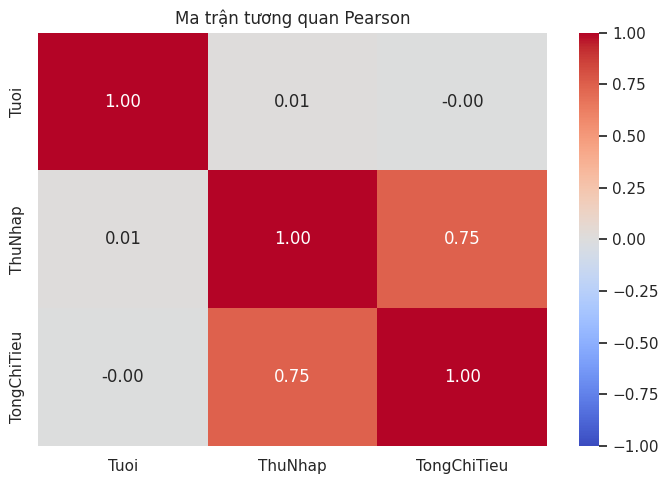

In [ ]:
cac_cot_so = ["Tuoi", "ThuNhap", "TongChiTieu"]
ma_tran_tuong_quan = df_khachhang[cac_cot_so].corr(method="pearson")

display(ma_tran_tuong_quan)

plt.figure(figsize=(7, 5))
sns.heatmap(
    ma_tran_tuong_quan,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Ma trận tương quan Pearson")
plt.tight_layout()
plt.show()


**Câu 10: Trực quan hóa dữ liệu (Data Visualization)**

Sử dụng matplotlib và seaborn để vẽ một biểu đồ Scatter Plot (Phân tán) thể hiện mối
quan hệ giữa ThuNhap (trục X) và TongChiTieu (trục Y). Tô màu các điểm dữ liệu dựa theo
GioiTinh (sử dụng tham số hue).


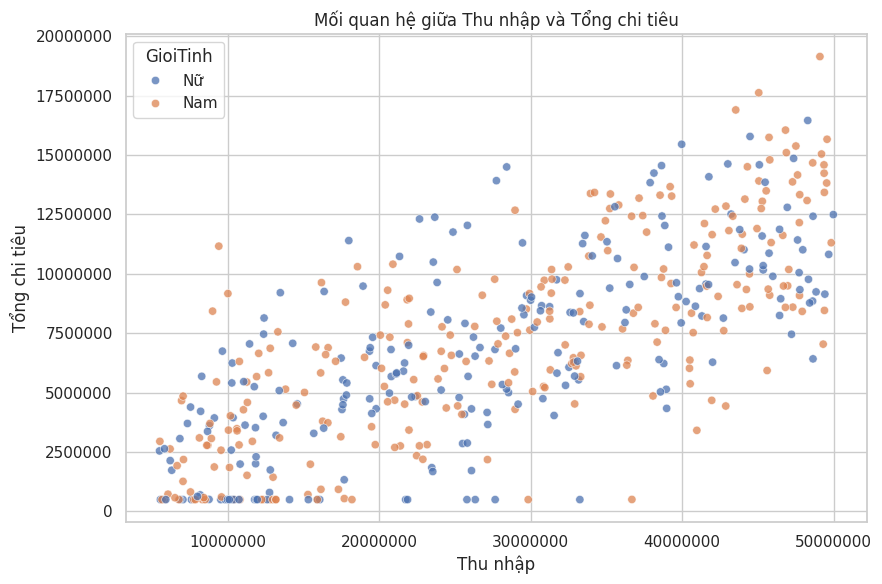

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_khachhang,
    x="ThuNhap",
    y="TongChiTieu",
    hue="GioiTinh",
    alpha=0.75
)

plt.title("Mối quan hệ giữa Thu nhập và Tổng chi tiêu")
plt.xlabel("Thu nhập")
plt.ylabel("Tổng chi tiêu")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


**Câu 11: Xây dựng và Huấn luyện mô hình CNN (Hình ảnh)**

Sử dụng thư viện TensorFlow/Keras hoặc PyTorch. Tải bộ dữ liệu hình ảnh Fashion
MNIST (phân loại quần áo, có sẵn trong keras.datasets).



In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Thiết lập seed cho TensorFlow
tf.random.set_seed(42)

# Tải Fashion MNIST
(x_train, y_train), (x_test, y_test) = (
    tf.keras.datasets.fashion_mnist.load_data()
)

print("Kích thước x_train ban đầu:", x_train.shape)
print("Kích thước x_test ban đầu:", x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước x_train ban đầu: (60000, 28, 28)
Kích thước x_test ban đầu: (10000, 28, 28)


In [ ]:
# Chuẩn hóa pixel từ [0, 255] về [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Thêm chiều kênh màu: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Kích thước x_train sau reshape:", x_train.shape)
print("Kích thước x_test sau reshape:", x_test.shape)


Kích thước x_train sau reshape: (60000, 28, 28, 1)
Kích thước x_test sau reshape: (10000, 28, 28, 1)


In [ ]:
# Xây dựng mô hình CNN
model = Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Biên dịch mô hình
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Huấn luyện mô hình trong 5 epochs
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8482 - loss: 0.4325 - val_accuracy: 0.8780 - val_loss: 0.3433
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8954 - loss: 0.2935 - val_accuracy: 0.8950 - val_loss: 0.2954
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9085 - loss: 0.2529 - val_accuracy: 0.9023 - val_loss: 0.2706
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9184 - loss: 0.2236 - val_accuracy: 0.9088 - val_loss: 0.2589
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9274 - loss: 0.1999 - val_accuracy: 0.9120 - val_loss: 0.2524


In [ ]:
# Đánh giá trên tập kiểm thử
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")


Test Loss: 0.2707
Test Accuracy: 0.9042
Test Accuracy (%): 90.42%


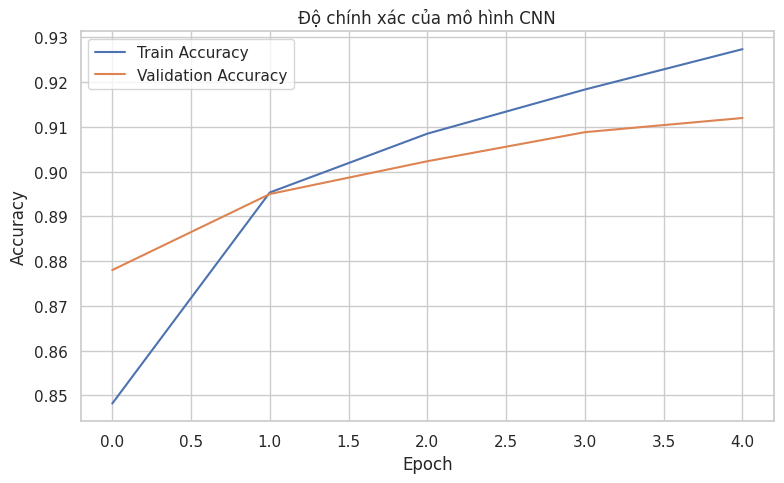

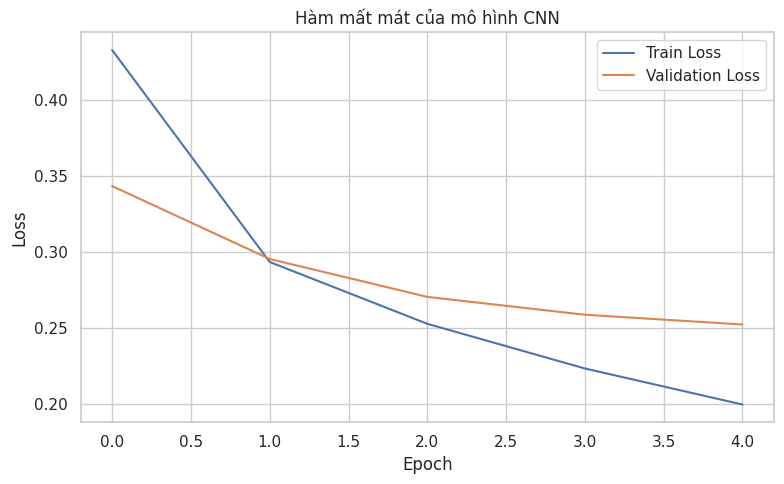

In [ ]:
# Vẽ độ chính xác trong quá trình huấn luyện
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Độ chính xác của mô hình CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Vẽ loss trong quá trình huấn luyện
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Hàm mất mát của mô hình CNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


### Nhận xét

- Mô hình CNN sử dụng lớp tích chập để tự động học các đặc trưng hình ảnh như đường nét, hình dạng và cấu trúc của quần áo.
- Chuẩn hóa dữ liệu về `[0, 1]` giúp mô hình huấn luyện ổn định hơn.
- `MaxPooling2D` làm giảm kích thước đặc trưng và số lượng phép tính.
- Lớp đầu ra gồm 10 neuron tương ứng với 10 loại sản phẩm trong Fashion MNIST.
- Độ chính xác thực tế có thể thay đổi nhẹ tùy môi trường chạy, seed và phiên bản TensorFlow.
